Title: RL_comparison.ipynb

Purpose: Compare Residual Load from ERA5 and SMARD

Author: Onno Nennecke on 10.07.2025 Modified: 18.07.2025

Input data: 

- adjusted final model output    - This file lies here: 

Output data:

- 

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob

# Importing functions

### Read Model output data

In [ ]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
ts_datasets = xr.open_dataset(path)
ts_datasets

<xarray.Dataset> Size: 43MB
Dimensions:            (ESM_run: 102, time: 3650)
Coordinates:
    crs                int64 8B ...
    gridtype           <U6 24B ...
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB ...
    run                (ESM_run) <U10 4kB ...
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country            float64 8B ...
    period             <U4 16B ...
    doy                (time) int64 29kB ...
Data variables: (12/16)
    temp               (ESM_run, time) float64 3MB ...
    demand             (ESM_run, time) float64 3MB ...
    sfcWind            (ESM_run, time) float64 3MB ...
    rsds               (ESM_run, time) float32 1MB ...
    tas                (ESM_run, time) float32 1MB ...
    tasmax             (ESM_run, time) float32 1MB ...
    ...                 ...
    Netto              (ESM_run, time) float64 3MB ...
    Residual_load      (ESM_run, time) float64 3MB ...
    solar_prod_adj     (ESM_run, time) float64 3MB ...
    total_prod_adj     (ESM_run, time) float64 3MB ...
    Netto_adjusted     (ESM_run, time) float64 3MB ...
    Residual_load_adj  (ESM_run, time) float64 3MB ...

In [3]:
ERA5_wwd = ts_datasets.sel(ESM_run='ERA5_hist_wwd')
ERA5_week = ts_datasets.sel(ESM_run='ERA5_hist_week')
SMARD = ts_datasets.sel(ESM_run='SMARD_hist')

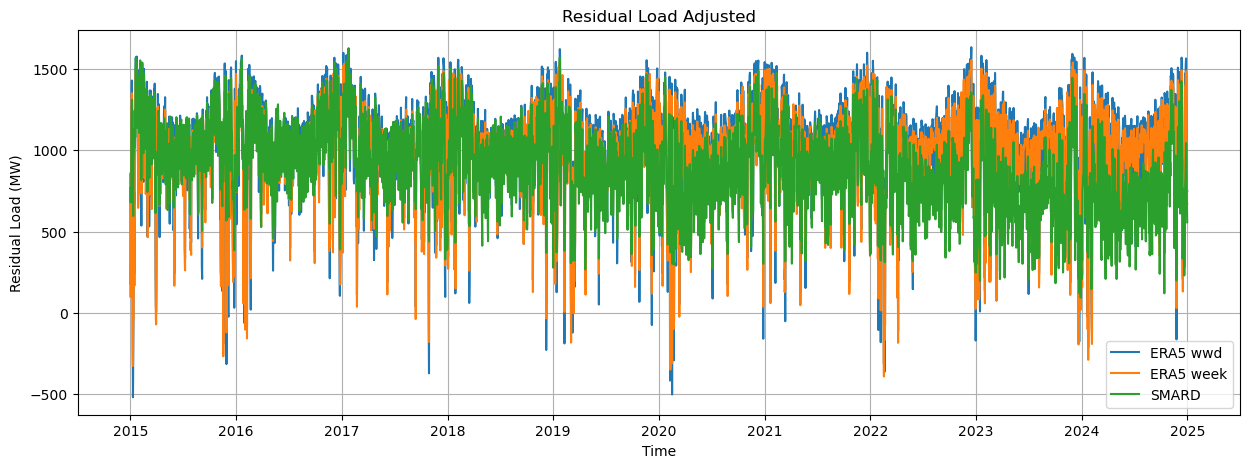

In [13]:
# Make a timeseries plot of Residual_load_adj for the three datasets
plt.figure(figsize=(15, 5))
ERA5_wwd.Residual_load_adj.plot(label='ERA5 wwd')
ERA5_week.Residual_load_adj.plot(label='ERA5 week')
SMARD.Residual_load_adj.plot(label='SMARD')
plt.title('Residual Load Adjusted')
plt.xlabel('Time')
plt.ylabel('Residual Load (MW)')
plt.legend()
plt.grid()
plt.show()

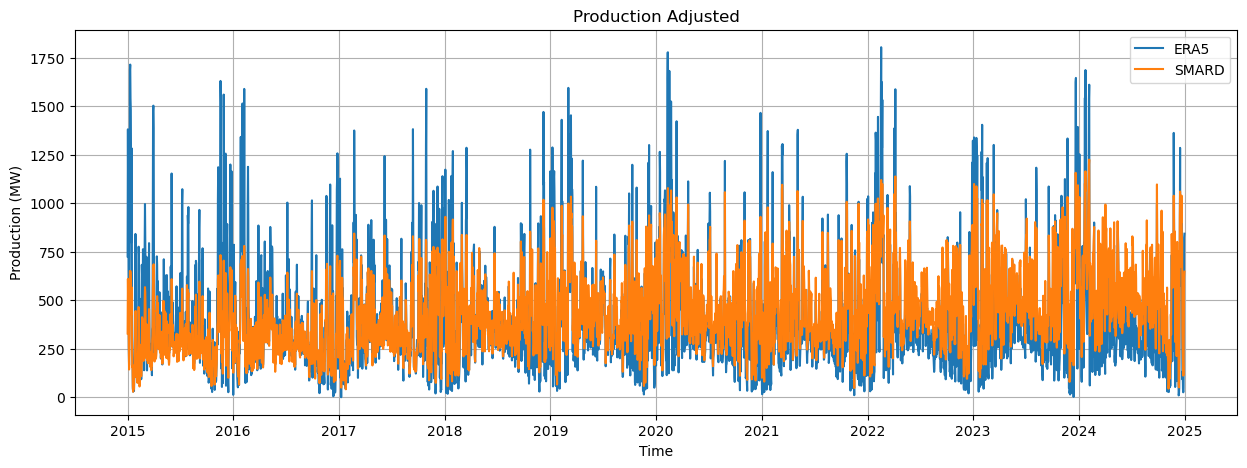

In [15]:
# Make a timeseries plot of Residual_load_adj for the three datasets
plt.figure(figsize=(15, 5))
ERA5_week.total_prod_adj.plot(label='ERA5')
SMARD.total_prod_adj.plot(label='SMARD')
plt.title('Production Adjusted')
plt.xlabel('Time')
plt.ylabel('Production (MW)')
plt.legend()
plt.grid()
plt.show()